In [4]:
# import stuff
import asymmetree.treeevolve as te
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import FunctionsTony
import copy

from asymmetree.visualization.tree_vis import visualize, assign_colors
from collections import defaultdict
from networkx.drawing.nx_pydot import graphviz_layout

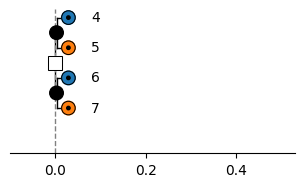

In [5]:

speciesTree, geneTree = FunctionsTony.generateTree(2,2)

# get color dicts
species_colors, gene_colors = assign_colors(speciesTree, geneTree)
# visualize asymetree tree
visualize(geneTree, color_dict=gene_colors)

# reverse dict so every color has a list of leaves attached to it, for visualization
color_to_keys = defaultdict(list)
for key, color in gene_colors.items():
    color_to_keys[tuple(color)].append(key)

In [6]:
# convert to networkx
Tree = FunctionsTony.convert_to_nx(geneTree)

# Original BMG:
BMG = FunctionsTony.bmg(Tree)
BC = FunctionsTony.biccherry(BMG)
BMGBC = FunctionsTony.bmg(BC)

print(nx.utils.graphs_equal(BMG, BMGBC))

# network = insertHybrid.insertHybrid(N, 1)

True


Es konnten 2 Hybride eingefügt werden, bevor die BMGs nicht mehr übereinstimmten


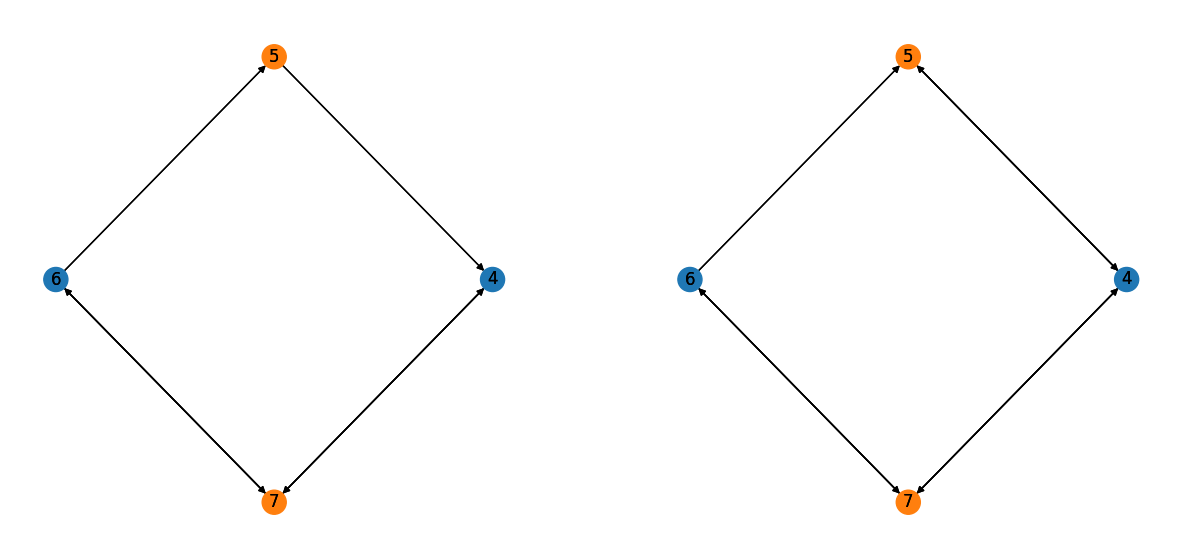

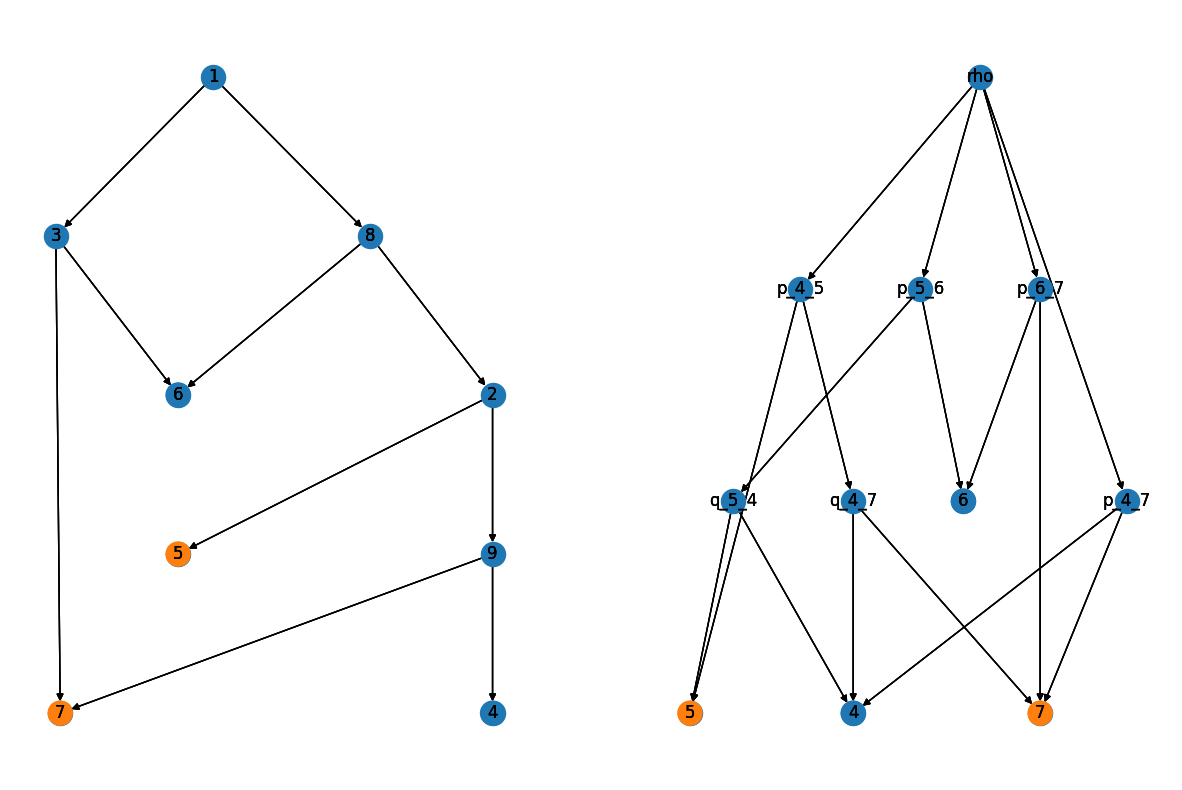

In [7]:
# Testen, wie viele Hybride man einfügen kann, bevor die beiden BMGs nicht mehr übereinstimmen
random.seed(1)
count = 0
Network = copy.deepcopy(Tree)
BMG = FunctionsTony.bmg(Tree)
BC = FunctionsTony.biccherry(BMG)
BMGBC = FunctionsTony.bmg(BC)

while nx.utils.graphs_equal(BMG, BMGBC) and count < 1000:
    Network = FunctionsTony.insertHybrid(Network)
    BMG = FunctionsTony.bmg(Network, mode = "weak")
    BC = FunctionsTony.biccherry(BMG)
    BMGBC = FunctionsTony.bmg(BC, mode = "weak")
    count += 1
    if count % 10 == 0:
        print("Count = ",count)

print("Es konnten",count,"Hybride eingefügt werden, bevor die BMGs nicht mehr übereinstimmten")

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
# Tree BMG
for color, node_list in color_to_keys.items():
    nx.draw(BMG, nx.circular_layout(BMG), nodelist=node_list, node_color=[color] * len(node_list), ax=axes[0], with_labels=True)
# network BMG
for color, node_list in color_to_keys.items():
    nx.draw(BMGBC, nx.circular_layout(BMGBC), nodelist=node_list, node_color=[color] * len(node_list), ax=axes[1], with_labels=True)

# visualize tree and network
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

# pos = insert_hybrid.calculate_time_tree_layout(network)

nx.draw(Network, graphviz_layout(Network, prog="dot"), with_labels = True, ax=axes[0])
for color, node_list in color_to_keys.items():
    nx.draw(Network, graphviz_layout(Network, prog="dot"), nodelist=node_list, node_color=[color] * len(node_list), with_labels=True, ax=axes[0])

nx.draw(BC, graphviz_layout(BC, prog="dot"), with_labels = True, ax=axes[1])
for color, node_list in color_to_keys.items():
    nx.draw(BC, graphviz_layout(BC, prog="dot"), nodelist=node_list, node_color=[color] * len(node_list), with_labels=True, ax=axes[1])
